# 12 — Robustness, Fairness, and Aggregated Drivers

This notebook extends the core analysis with four add-on studies:

1. **Aggregated drivers across seeds** — family importance, HP importance, and rule feature frequency
2. **Margin vs variance** — are hotspots simply near the decision boundary?
3. **Fairness / subgroup exposure** — are HH/HV regions overrepresented for sensitive groups (COMPAS)?
4. **Alternative kNN graph** — PCA-reduced and cosine-distance graphs

In [1]:
import sys, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Robust project-root detection whether launched from repo root or notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if not (ROOT / "analysis").exists():
    if (Path.cwd() / "analysis").exists():
        ROOT = Path.cwd()
    elif (Path.cwd().parent / "analysis").exists():
        ROOT = Path.cwd().parent

for p in [str(ROOT), str(ROOT / "src")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from analysis.run_analysis import (
    load_meta, load_P_test, load_split,
    select_rashomon_global,
    select_rashomon_per_family_totalK,
    select_rashomon_per_family_k_each,
    pointwise_variance, spatial_analysis, run_spatial,
)
from analysis.preprocessing import get_transformed_test_features
from analysis.hyperparams import (
    ensure_hp_columns, compute_family_importance,
    compute_within_family_hp_importance,
    compute_within_family_hp_importance_on_subset,
)
from data import load_dataset, make_preprocessor

RESULTS = ROOT / "results"
TABLES  = ROOT / "tables"
FIGURES = ROOT / "figures"
TABLES.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

K = 25
K_NN = 30
SEEDS = list(range(10))
DATASETS = ["compas", "german", "breast_cancer"]

print(f"ROOT={ROOT}")
print(f"K={K}, k_nn={K_NN}, seeds={SEEDS}, datasets={DATASETS}")

ROOT=c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity
K=25, k_nn=30, seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], datasets=['compas', 'german', 'breast_cancer']


---
## 1. Aggregate Drivers Across Seeds

### 1a. Family importance (mean ± std across seeds)

In [2]:
fam_imp_rows = []

for dataset in DATASETS:
    for seed in SEEDS:
        run_dir = RESULTS / dataset / f"seed={seed}"
        try:
            meta = load_meta(run_dir)
            P_test = load_P_test(run_dir)
            idx = select_rashomon_per_family_k_each(run_dir, K_each=K)
            P_sel = P_test[idx]
            meta_sel = meta.iloc[idx].reset_index(drop=True)
            
            # Global family importance
            fi_all = compute_family_importance(meta_sel, P_sel)
            
            # HH-specific family importance
            X_test = get_transformed_test_features(run_dir, dataset)
            v = pointwise_variance(P_sel)
            sp = spatial_analysis(v, X_test, k=K_NN, permutations=999)
            hh_mask = sp["HH_mask"]
            n_hh = int(hh_mask.sum())
            
            fi_hh_ratio = np.nan
            if n_hh >= 5:
                fi_hh = compute_family_importance(meta_sel, P_sel, obs_mask=hh_mask)
                fi_hh_ratio = fi_hh["ratio_of_sums"].values[0]
            
            fam_imp_rows.append({
                "dataset": dataset,
                "seed": seed,
                "ratio_of_sums_all": fi_all["ratio_of_sums"].values[0],
                "mean_ratio_all": fi_all["mean_ratio"].values[0],
                "ratio_of_sums_hh": fi_hh_ratio,
                "n_hh": n_hh,
            })
            print(f"  {dataset} seed={seed}: ratio_all={fi_all['ratio_of_sums'].values[0]:.3f}, "
                  f"ratio_hh={fi_hh_ratio:.3f}, n_hh={n_hh}")
        except Exception as e:
            print(f"  {dataset} seed={seed}: SKIP ({e})")

df_fam_imp = pd.DataFrame(
    fam_imp_rows,
    columns=[
        "dataset", "seed", "ratio_of_sums_all", "mean_ratio_all",
        "ratio_of_sums_hh", "n_hh",
    ],
)
print(f"\nCollected {len(df_fam_imp)} rows")

  compas seed=0: ratio_all=0.389, ratio_hh=0.535, n_hh=127
  compas seed=1: ratio_all=0.438, ratio_hh=0.524, n_hh=141
  compas seed=2: ratio_all=0.417, ratio_hh=0.500, n_hh=93
  compas seed=3: ratio_all=0.393, ratio_hh=0.536, n_hh=112
  compas seed=4: ratio_all=0.367, ratio_hh=0.490, n_hh=89
  compas seed=5: ratio_all=0.420, ratio_hh=0.518, n_hh=135
  compas seed=6: ratio_all=0.440, ratio_hh=0.544, n_hh=111
  compas seed=7: ratio_all=0.386, ratio_hh=0.462, n_hh=80
  compas seed=8: ratio_all=0.467, ratio_hh=0.585, n_hh=162
  compas seed=9: ratio_all=0.410, ratio_hh=0.552, n_hh=75
  german seed=0: ratio_all=0.490, ratio_hh=0.536, n_hh=7
  german seed=1: ratio_all=0.567, ratio_hh=nan, n_hh=4
  german seed=2: ratio_all=0.544, ratio_hh=nan, n_hh=3
  german seed=3: ratio_all=0.580, ratio_hh=0.584, n_hh=7
  german seed=4: ratio_all=0.564, ratio_hh=nan, n_hh=2
  german seed=5: ratio_all=0.498, ratio_hh=nan, n_hh=4
  german seed=6: ratio_all=0.463, ratio_hh=nan, n_hh=1
  german seed=7: ratio_al

In [3]:
def _ms(s):
    return f"{s.mean():.3f} ± {s.std():.3f}"

required_cols = {"dataset", "seed", "ratio_of_sums_all", "ratio_of_sums_hh"}
has_dataset = "dataset" in getattr(df_fam_imp, "columns", [])
can_agg = not df_fam_imp.empty and has_dataset and required_cols.issubset(df_fam_imp.columns)
if not can_agg:
    print("No family-importance rows available. Check setup/output from previous cell.")
    print(f"df_fam_imp shape={df_fam_imp.shape}, columns={list(df_fam_imp.columns)}")
    agg_fam = pd.DataFrame(columns=[
        "dataset", "ratio_all_mean", "ratio_all_std",
        "ratio_hh_mean", "ratio_hh_std", "n_seeds", "n_seeds_hh",
    ])
else:
    agg_fam = df_fam_imp.groupby("dataset").agg(
        ratio_all_mean=("ratio_of_sums_all", "mean"),
        ratio_all_std=("ratio_of_sums_all", "std"),
        ratio_hh_mean=("ratio_of_sums_hh", lambda x: x.dropna().mean()),
        ratio_hh_std=("ratio_of_sums_hh", lambda x: x.dropna().std()),
        n_seeds=("seed", "count"),
        n_seeds_hh=("ratio_of_sums_hh", lambda x: x.notna().sum()),
    ).reset_index()

print("Family importance (ratio_of_sums) aggregated across seeds:")
display(agg_fam)

agg_fam.to_csv(TABLES / "family_importance_aggregated.csv", index=False)

Family importance (ratio_of_sums) aggregated across seeds:


,dataset,ratio_all_mean,ratio_all_std,ratio_hh_mean,ratio_hh_std,n_seeds,n_seeds_hh
0,breast_cancer,0.619788,0.052815,0.688324,0.049712,10,4
1,compas,0.412613,0.030182,0.524605,0.034582,10,10
2,german,0.530622,0.042499,0.533854,0.050913,10,3


### 1b. Within-family HP importance aggregated across seeds

In [4]:
hp_imp_rows = []

for dataset in DATASETS:
    for seed in SEEDS:
        run_dir = RESULTS / dataset / f"seed={seed}"
        try:
            meta = load_meta(run_dir)
            P_test = load_P_test(run_dir)
            idx = select_rashomon_per_family_k_each(run_dir, K_each=K)
            P_sel = P_test[idx]
            meta_sel = meta.iloc[idx].reset_index(drop=True)
            
            hp_df = compute_within_family_hp_importance(meta_sel, P_sel)
            if len(hp_df) > 0:
                hp_df["dataset"] = dataset
                hp_df["seed"] = seed
                hp_imp_rows.append(hp_df)
        except Exception as e:
            print(f"  {dataset} seed={seed}: SKIP ({e})")

df_hp_imp = pd.concat(hp_imp_rows, ignore_index=True)
print(f"Collected {len(df_hp_imp)} HP importance rows across all seeds")

Collected 535 HP importance rows across all seeds


In [5]:
# Aggregate: mean ± std of ratio_of_sums per (dataset, family, hp)
agg_hp = df_hp_imp.groupby(["dataset", "family", "hp"]).agg(
    ratio_mean=("ratio_of_sums", "mean"),
    ratio_std=("ratio_of_sums", "std"),
    n_seeds=("seed", "count"),
).reset_index()

# Top 5 per (dataset, family)
top_hp = agg_hp.sort_values(["dataset", "family", "ratio_mean"], ascending=[True, True, False])
top_hp = top_hp.groupby(["dataset", "family"]).head(5).reset_index(drop=True)

print("Top 5 HPs per family (aggregated across seeds):")
display(top_hp)

top_hp.to_csv(TABLES / "hp_importance_aggregated_top5.csv", index=False)

Top 5 HPs per family (aggregated across seeds):


,dataset,family,hp,ratio_mean,ratio_std,n_seeds
0,breast_cancer,GBM,max_depth,0.267705,0.100101,10
1,breast_cancer,GBM,subsample,0.225961,0.144739,10
2,breast_cancer,GBM,learning_rate,0.205104,0.105999,10
3,breast_cancer,GBM,n_estimators,0.139979,0.086136,10
4,breast_cancer,LogReg,C,0.974307,0.030219,10
5,breast_cancer,LogReg,l1_ratio,0.127473,0.069030,10
6,breast_cancer,MLP,learning_rate_init,0.238012,0.101495,10
7,breast_cancer,MLP,hidden_layer_sizes,0.175220,0.051949,10
8,breast_cancer,MLP,alpha,0.102009,0.052314,10
9,breast_cancer,MLP,activation,0.057274,0.039245,10


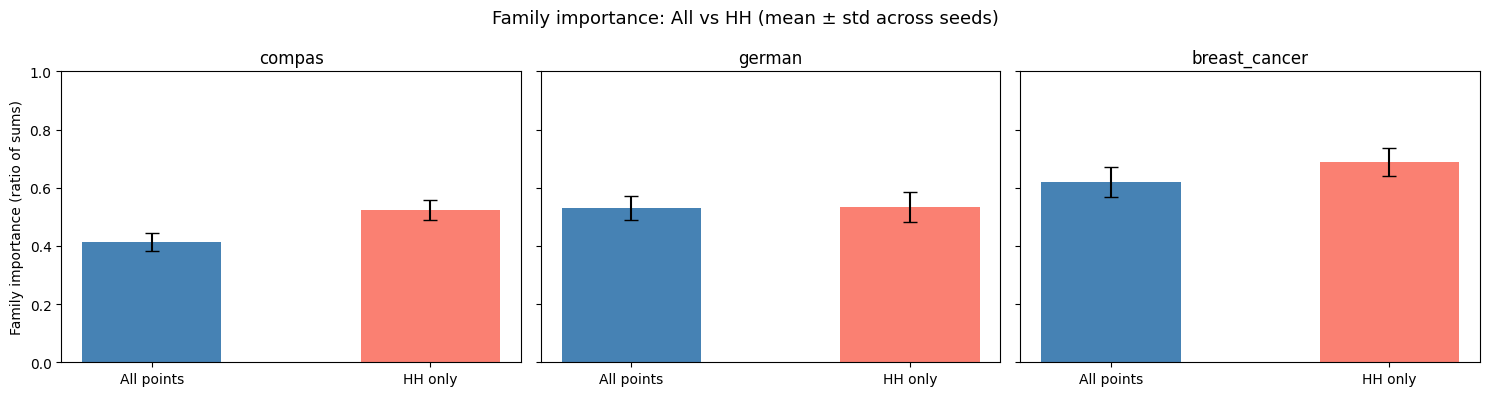

In [6]:
# Bar plot: family importance across seeds (for each dataset)
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5*len(DATASETS), 4), sharey=True)
if len(DATASETS) == 1:
    axes = [axes]

for ax, ds in zip(axes, DATASETS):
    sub = df_fam_imp[df_fam_imp["dataset"] == ds]
    vals_all = sub["ratio_of_sums_all"]
    vals_hh = sub["ratio_of_sums_hh"].dropna()
    
    x = [0, 1]
    means = [vals_all.mean(), vals_hh.mean() if len(vals_hh) else 0]
    stds  = [vals_all.std(), vals_hh.std() if len(vals_hh) else 0]
    
    bars = ax.bar(x, means, yerr=stds, capsize=5, color=["steelblue", "salmon"], width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(["All points", "HH only"])
    ax.set_title(ds)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Family importance (ratio of sums)")
fig.suptitle("Family importance: All vs HH (mean ± std across seeds)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / "family_importance_aggregated.pdf", bbox_inches="tight")
plt.show()

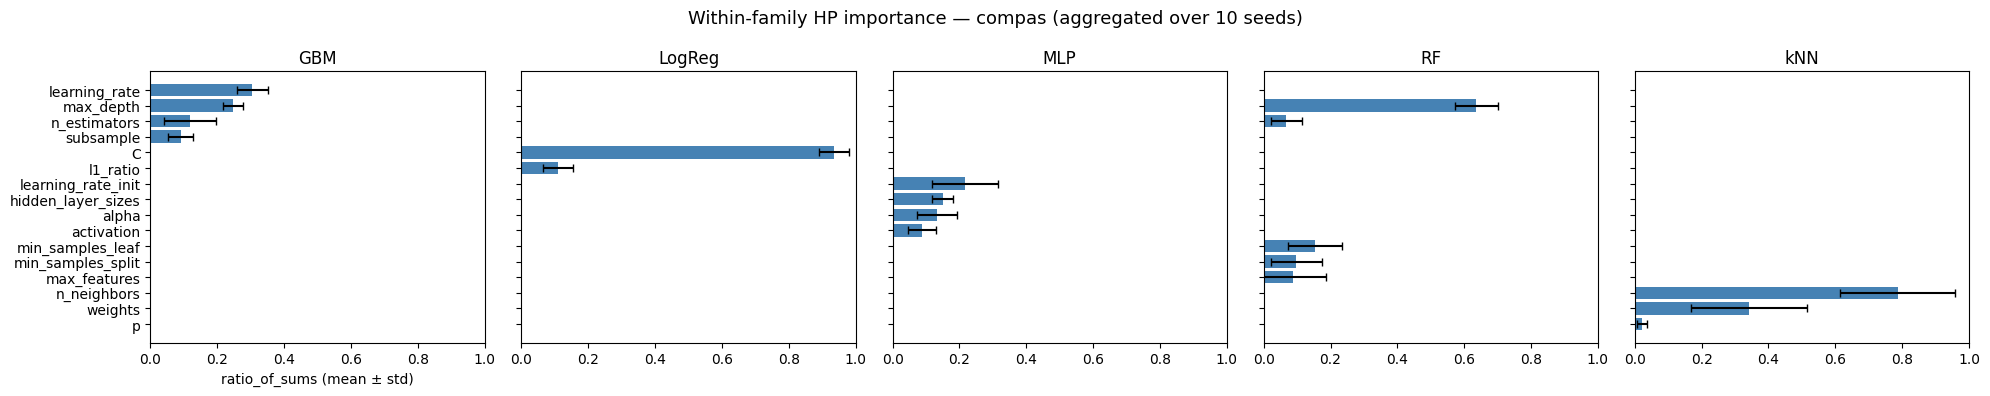

In [7]:
# Bar plot: top HP importance for COMPAS (selected families)
ds_focus = "compas"
sub = top_hp[top_hp["dataset"] == ds_focus]
families = sub["family"].unique()

fig, axes = plt.subplots(1, len(families), figsize=(4*len(families), 4), sharey=True)
if len(families) == 1:
    axes = [axes]

for ax, fam in zip(axes, families):
    fam_sub = sub[sub["family"] == fam].head(5)
    ax.barh(fam_sub["hp"], fam_sub["ratio_mean"], xerr=fam_sub["ratio_std"],
            capsize=3, color="steelblue")
    ax.set_title(fam)
    ax.set_xlim(0, 1)
    ax.invert_yaxis()

axes[0].set_xlabel("ratio_of_sums (mean ± std)")
fig.suptitle(f"Within-family HP importance — {ds_focus} (aggregated over {len(SEEDS)} seeds)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / f"hp_importance_aggregated_{ds_focus}.pdf", bbox_inches="tight")
plt.show()

### 1c. Rule feature frequency across seeds

In [8]:
# Read existing rule stability tables (generated by notebook 11)
rule_tables = {}
for ds in DATASETS:
    path = TABLES / f"rule_stability_{ds}.csv"
    if path.exists():
        rule_tables[ds] = pd.read_csv(path)
        print(f"{ds}: {len(rule_tables[ds])} rule stability rows")
    else:
        print(f"{ds}: no rule_stability table found")

compas: 730 rule stability rows
german: 269 rule stability rows
breast_cancer: 109 rule stability rows


In [9]:
# Also check rule_feature_stability if it exists
feat_stab_path = TABLES / "rule_feature_stability_compas.csv"
if feat_stab_path.exists():
    df_feat_stab = pd.read_csv(feat_stab_path)
    print("Existing rule_feature_stability_compas.csv:")
    display(df_feat_stab.head(10))
else:
    print("No pre-existing feature stability table; will extract from rules.")

Existing rule_feature_stability_compas.csv:


,label,type,name,frequency
0,HV_q,feature,num__age,10.60
1,HV_q,feature,num__priors_count,10.02
2,HH,feature,num__priors_count,8.36
3,HH,feature,num__age,8.06
4,HV_q,feature,cat__race_African-American,2.84
5,HV_q,feature,cat__race_Other,2.32
6,HV_q,feature,cat__race_Caucasian,1.50
7,HV_q,feature,cat__sex_Female,1.36
8,HV_q,feature,cat__race_Asian,1.24
9,HV_q,feature,cat__sex_Male,0.98


In [10]:
# Extract top features from rules across seeds
# Read rules_summary tables and parse feature names from rule strings
import re

def extract_features_from_rules(rules_df, feature_col="rule"):
    """Extract feature names mentioned in rule strings."""
    all_feats = []
    if feature_col not in rules_df.columns:
        for col in ["rule_text", "rule_string", "description"]:
            if col in rules_df.columns:
                feature_col = col
                break
        else:
            return pd.Series(dtype=float)
    
    for rule_str in rules_df[feature_col].dropna():
        # Match patterns like "feature_name <= X" or "feature_name > X"
        feats = re.findall(r'([a-zA-Z_][a-zA-Z0-9_]*(?:__[a-zA-Z0-9_]+)*)\s*[<>=!]+', str(rule_str))
        all_feats.extend(feats)
    
    if not all_feats:
        return pd.Series(dtype=float)
    return pd.Series(all_feats).value_counts()

for ds in DATASETS:
    path = TABLES / f"rules_summary_{ds}.csv"
    if path.exists():
        rules_df = pd.read_csv(path)
        print(f"\n=== {ds} ===")
        print(f"Columns: {list(rules_df.columns)}")
        freq = extract_features_from_rules(rules_df)
        if len(freq):
            print(f"Top features in rules:")
            print(freq.head(10))
        else:
            print("Could not parse features from rule strings.")
    else:
        print(f"No rules_summary for {ds}")


=== compas ===
Columns: ['method', 'label', 'rule', 'support', 'purity', 'recall', 'lift']
Top features in rules:
num__age                  64
num__priors_count         50
American                  10
cat__race_Other            8
cat__sex_Female            7
cat__race_Asian            5
cat__c_charge_degree_M     3
cat__c_charge_degree_F     3
cat__sex_Male              2
cat__race_Hispanic         2
Name: count, dtype: int64

=== german ===
Columns: ['method', 'label', 'rule', 'support', 'precision', 'recall', 'lift']
Top features in rules:
num__credit_amount               15
cat__other_payment_plans_bank    11
mgmt                              5
X                                 4
num__installment_commitment       4
num__age                          3
car                               3
equipment                         2
paid                              2
cat__job_skilled                  2
Name: count, dtype: int64

=== breast_cancer ===
Columns: ['method', 'label', 'rule', 'supp

In [11]:
# More robust approach: read the final_rules tables
for ds in ["compas"]:
    path = TABLES / f"final_rules_{ds}.csv"
    if path.exists():
        final_rules = pd.read_csv(path)
        print(f"final_rules_{ds}.csv columns: {list(final_rules.columns)}")
        display(final_rules.head(10))

final_rules_compas.csv columns: ['label', 'method', 'rule_text', 'support', 'purity', 'recall', 'lift', 'OOB_purity_median', 'permutation_pval']


,label,method,rule_text,support,purity,recall,lift,OOB_purity_median,permutation_pval
0,HH,beam_search,num__priors_count > 0.3237 AND num__age > 0.68...,50,0.560000,0.595745,17.193191,0.332044,0.001996
1,HH,beam_search,num__priors_count > 0.3237 AND num__age > 0.68...,54,0.555556,0.638298,17.056738,0.332044,0.001996
2,HH,beam_search,num__priors_count > 0.3237 AND num__age > 0.68...,59,0.491525,0.617021,15.090876,0.332044,0.001996
3,HH,beam_search,num__priors_count > 0.3237 AND num__age > 0.68...,59,0.491525,0.617021,15.090876,0.332044,0.001996
4,HH,beam_search,num__priors_count > 0.3237 AND num__age > 0.68...,76,0.486842,0.787234,14.947088,0.332044,0.001996
5,HV_q,cluster_describe,Cluster0: num__priors_count > 0.8414 AND num__...,44,0.727273,0.217687,7.139147,NaN,0.001996
6,HV_q,cluster_describe,Cluster1: num__age <= -0.8588 AND num__age <= ...,31,0.612903,0.129252,6.016458,NaN,0.001996
7,HV_q,beam_search,num__priors_count > 0.3237 AND num__age > 0.6846,83,0.481928,0.272109,4.730760,0.420952,0.001996
8,HV_q,beam_search,cat__race_Other > 0,83,0.277108,0.156463,2.720187,0.420952,0.001996
9,HV_q,cluster_describe,Cluster1: num__age <= -0.8588 AND num__age > -...,88,0.261364,0.156463,2.565631,NaN,0.001996


In [12]:
# Aggregate rule feature frequency across all rule tables
# Approach: for each dataset, look for columns that contain feature names

feature_freq_all = {}

for ds in DATASETS:
    all_feats = []
    for tbl_name in [f"rules_summary_{ds}.csv", f"final_rules_{ds}.csv"]:
        path = TABLES / tbl_name
        if not path.exists():
            continue
        df = pd.read_csv(path)
        # Try to extract features from any text column that might contain rules
        for col in df.columns:
            if df[col].dtype == object:
                for val in df[col].dropna():
                    feats = re.findall(
                        r'([a-zA-Z_][a-zA-Z0-9_]*(?:__[a-zA-Z0-9_]+)*)\s*[<>=!]+',
                        str(val)
                    )
                    all_feats.extend(feats)
    
    if all_feats:
        freq = pd.Series(all_feats).value_counts()
        feature_freq_all[ds] = freq
        print(f"\n{ds} — Top 10 features in rules:")
        print(freq.head(10))
    else:
        print(f"\n{ds} — No features extracted")

# Save feature frequency table for COMPAS
if "compas" in feature_freq_all:
    freq_df = feature_freq_all["compas"].reset_index()
    freq_df.columns = ["feature", "frequency"]
    freq_df.to_csv(TABLES / "rule_feature_frequency_compas.csv", index=False)
    print("\nSaved rule_feature_frequency_compas.csv")


compas — Top 10 features in rules:
num__age                  76
num__priors_count         58
American                  12
cat__race_Other            9
cat__sex_Female            8
cat__race_Asian            5
cat__c_charge_degree_M     4
cat__c_charge_degree_F     4
cat__sex_Male              2
cat__race_Hispanic         2
Name: count, dtype: int64

german — Top 10 features in rules:
num__credit_amount               15
cat__other_payment_plans_bank    11
mgmt                              5
X                                 4
num__installment_commitment       4
num__age                          3
car                               3
equipment                         2
paid                              2
cat__job_skilled                  2
Name: count, dtype: int64

breast_cancer — Top 10 features in rules:
error          10
compactness     6
area            5
texture         5
perimeter       4
concavity       3
radius          2
points          1
smoothness      1
Name: count, dtype: i

---
## 2. Decision Boundary Analysis: Variance vs Margin

Test if HH/HV points are simply those near `p_mean = 0.5` (low margin).

In [13]:
margin_rows = []

for dataset in DATASETS:
    for seed in SEEDS:
        run_dir = RESULTS / dataset / f"seed={seed}"
        try:
            P_test = load_P_test(run_dir)
            idx_global = select_rashomon_global(run_dir, K=K)
            P_sel = P_test[idx_global]
            
            p_mean = P_sel.mean(axis=0)
            margin = np.abs(p_mean - 0.5)
            v = pointwise_variance(P_sel)
            
            # HV: top 10% by variance
            q90 = np.quantile(v, 0.90)
            hv_mask = v >= q90
            
            # HH from spatial analysis
            X_test = get_transformed_test_features(run_dir, dataset)
            sp = spatial_analysis(v, X_test, k=K_NN, permutations=999)
            hh_mask = sp["HH_mask"]
            
            # Correlations
            r_pearson, p_pearson = stats.pearsonr(v, margin)
            r_spearman, p_spearman = stats.spearmanr(v, margin)
            
            margin_rows.append({
                "dataset": dataset,
                "seed": seed,
                "pearson_r": r_pearson,
                "pearson_p": p_pearson,
                "spearman_r": r_spearman,
                "spearman_p": p_spearman,
                "margin_mean_hh": margin[hh_mask].mean() if hh_mask.sum() > 0 else np.nan,
                "margin_mean_non_hh": margin[~hh_mask].mean(),
                "margin_mean_hv": margin[hv_mask].mean(),
                "margin_mean_non_hv": margin[~hv_mask].mean(),
                "n_hh": int(hh_mask.sum()),
                "n_hv": int(hv_mask.sum()),
                "n_test": len(v),
            })
        except Exception as e:
            print(f"  {dataset} seed={seed}: SKIP ({e})")

df_margin = pd.DataFrame(margin_rows)
print(f"Collected {len(df_margin)} margin analysis rows")

Collected 30 margin analysis rows


In [14]:
# Summary table: correlation between variance and margin
agg_margin = df_margin.groupby("dataset").agg(
    pearson_r_mean=("pearson_r", "mean"),
    pearson_r_std=("pearson_r", "std"),
    spearman_r_mean=("spearman_r", "mean"),
    spearman_r_std=("spearman_r", "std"),
    margin_hh_mean=("margin_mean_hh", lambda x: x.dropna().mean()),
    margin_hh_std=("margin_mean_hh", lambda x: x.dropna().std()),
    margin_non_hh_mean=("margin_mean_non_hh", "mean"),
    margin_non_hh_std=("margin_mean_non_hh", "std"),
    margin_hv_mean=("margin_mean_hv", "mean"),
    margin_non_hv_mean=("margin_mean_non_hv", "mean"),
).reset_index()

print("Variance vs Margin correlation (aggregated):")
display(agg_margin)

agg_margin.to_csv(TABLES / "variance_vs_margin_summary.csv", index=False)

Variance vs Margin correlation (aggregated):


,dataset,pearson_r_mean,pearson_r_std,spearman_r_mean,spearman_r_std,margin_hh_mean,margin_hh_std,margin_non_hh_mean,margin_non_hh_std,margin_hv_mean,margin_non_hv_mean
0,breast_cancer,-0.852005,0.142707,-0.990308,0.010966,0.379842,0.062837,0.473946,0.010591,0.291397,0.494156
1,compas,-0.043352,0.091062,-0.074199,0.175108,0.193723,0.041370,0.177802,0.005368,0.172169,0.178242
2,german,-0.556165,0.131852,-0.695409,0.103495,0.155026,0.060514,0.257400,0.017834,0.135761,0.269457


In [15]:
# Wilcoxon rank-sum test: margin for HH vs non-HH (per dataset)
wilcoxon_rows = []

for dataset in DATASETS:
    for seed in SEEDS:
        run_dir = RESULTS / dataset / f"seed={seed}"
        try:
            P_test = load_P_test(run_dir)
            idx = select_rashomon_global(run_dir, K=K)
            P_sel = P_test[idx]
            p_mean = P_sel.mean(axis=0)
            margin = np.abs(p_mean - 0.5)
            v = pointwise_variance(P_sel)
            
            X_test = get_transformed_test_features(run_dir, dataset)
            sp = spatial_analysis(v, X_test, k=K_NN, permutations=999)
            hh_mask = sp["HH_mask"]
            
            if hh_mask.sum() >= 3 and (~hh_mask).sum() >= 3:
                stat, pval = stats.mannwhitneyu(
                    margin[hh_mask], margin[~hh_mask], alternative="less"
                )
                wilcoxon_rows.append({
                    "dataset": dataset, "seed": seed,
                    "U_stat": stat, "p_value": pval,
                    "margin_hh": margin[hh_mask].mean(),
                    "margin_non_hh": margin[~hh_mask].mean(),
                })
        except Exception:
            pass

df_wilcoxon = pd.DataFrame(wilcoxon_rows)
if len(df_wilcoxon):
    agg_w = df_wilcoxon.groupby("dataset").agg(
        mean_pval=("p_value", "mean"),
        frac_sig=("p_value", lambda x: (x < 0.05).mean()),
        margin_hh=("margin_hh", "mean"),
        margin_non_hh=("margin_non_hh", "mean"),
    ).reset_index()
    print("Mann-Whitney U: margin(HH) < margin(non-HH)?")
    display(agg_w)
    agg_w.to_csv(TABLES / "margin_hh_wilcoxon.csv", index=False)

Mann-Whitney U: margin(HH) < margin(non-HH)?


,dataset,mean_pval,frac_sig,margin_hh,margin_non_hh
0,breast_cancer,0.000342,1.000000,0.379842,0.483401
1,compas,0.588331,0.300000,0.193723,0.177802
2,german,0.147780,0.571429,0.155026,0.256291


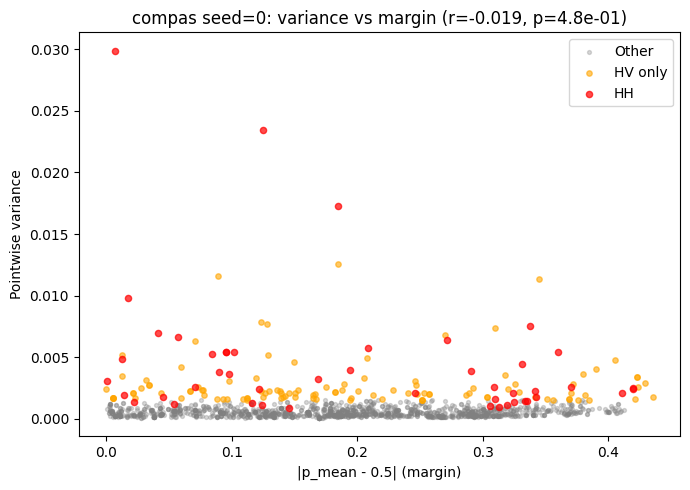

In [16]:
# Scatter plot: variance vs margin for COMPAS seed=0
ds_plot = "compas"
seed_plot = 0
run_dir = RESULTS / ds_plot / f"seed={seed_plot}"

P_test = load_P_test(run_dir)
idx = select_rashomon_global(run_dir, K=K)
P_sel = P_test[idx]
p_mean = P_sel.mean(axis=0)
margin = np.abs(p_mean - 0.5)
v = pointwise_variance(P_sel)

X_test = get_transformed_test_features(run_dir, ds_plot)
sp = spatial_analysis(v, X_test, k=K_NN, permutations=999)
hh_mask = sp["HH_mask"]
q90 = np.quantile(v, 0.90)
hv_mask = v >= q90

fig, ax = plt.subplots(figsize=(7, 5))
# Non-hotspot
other = ~hh_mask & ~hv_mask
ax.scatter(margin[other], v[other], s=8, alpha=0.3, c="gray", label="Other")
# HV only
hv_only = hv_mask & ~hh_mask
ax.scatter(margin[hv_only], v[hv_only], s=15, alpha=0.6, c="orange", label="HV only")
# HH
ax.scatter(margin[hh_mask], v[hh_mask], s=20, alpha=0.7, c="red", label="HH")

r, p = stats.pearsonr(v, margin)
ax.set_xlabel("|p_mean - 0.5| (margin)")
ax.set_ylabel("Pointwise variance")
ax.set_title(f"{ds_plot} seed={seed_plot}: variance vs margin (r={r:.3f}, p={p:.1e})")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES / f"variance_vs_margin_{ds_plot}.pdf", bbox_inches="tight")
plt.show()

---
## 3. Fairness / Subgroup Exposure (COMPAS)

Are HH/HV regions overrepresented for sensitive groups (race, sex)?

In [17]:
X_raw, y_raw, feature_info = load_dataset("compas")
print(f"COMPAS features: {list(X_raw.columns)}")
print(f"Race values: {X_raw['race'].value_counts().to_dict()}")
print(f"Sex values: {X_raw['sex'].value_counts().to_dict()}")

COMPAS features: ['age', 'priors_count', 'sex', 'race', 'c_charge_degree']
Race values: {'African-American': 3696, 'Caucasian': 2454, 'Hispanic': 637, 'Other': 377, 'Asian': 32, 'Native American': 18}
Sex values: {'Male': 5819, 'Female': 1395}


In [18]:
fairness_rows = []
_fairness_cache = {}  # {seed: (hh_mask, X_test_raw_df)} for reuse in permutation tests
MIN_GROUP_N = 30      # Minimum per-seed subgroup size for significance reporting

for seed in SEEDS:
    run_dir = RESULTS / "compas" / f"seed={seed}"
    try:
        split = load_split(run_dir)
        test_idx = split["test"]
        X_test_raw_i = X_raw.iloc[test_idx]

        P_test = load_P_test(run_dir)
        idx = select_rashomon_global(run_dir, K=K)
        P_sel = P_test[idx]
        v = pointwise_variance(P_sel)

        # HV: top 10%
        q90 = np.quantile(v, 0.90)
        hv_mask = v >= q90

        # HH from spatial analysis
        X_test_proc = get_transformed_test_features(run_dir, "compas")
        sp = spatial_analysis(v, X_test_proc, k=K_NN, permutations=999)
        hh_mask = sp["HH_mask"]

        _fairness_cache[seed] = (hh_mask, X_test_raw_i)

        for group_col in ["race", "sex"]:
            group_vals = X_test_raw_i[group_col].values
            for g in np.unique(group_vals):
                g_mask = group_vals == g
                n_group = int(g_mask.sum())
                fairness_rows.append({
                    "seed": seed,
                    "group_col": group_col,
                    "group_val": g,
                    "n_group": n_group,
                    "n_test": len(v),
                    "eligible_sig": n_group >= MIN_GROUP_N,
                    "hh_rate": hh_mask[g_mask].mean() if n_group > 0 else np.nan,
                    "hv_rate": hv_mask[g_mask].mean() if n_group > 0 else np.nan,
                    "mean_variance": v[g_mask].mean() if n_group > 0 else np.nan,
                })
    except Exception as e:
        print(f"  seed={seed}: SKIP ({e})")

df_fair = pd.DataFrame(fairness_rows)
print(f"Collected {len(df_fair)} fairness rows")
print(f"Significance threshold: min subgroup size per seed = {MIN_GROUP_N}")

Collected 80 fairness rows
Significance threshold: min subgroup size per seed = 30


In [19]:
# Aggregate: mean ± std across seeds per group
agg_fair = df_fair.groupby(["group_col", "group_val"]).agg(
    hh_rate_mean=("hh_rate", "mean"),
    hh_rate_std=("hh_rate", "std"),
    hv_rate_mean=("hv_rate", "mean"),
    hv_rate_std=("hv_rate", "std"),
    mean_var_mean=("mean_variance", "mean"),
    mean_var_std=("mean_variance", "std"),
    n_seeds=("seed", "count"),
    n_seed_eligible=("eligible_sig", "sum"),
    n_group_mean=("n_group", "mean"),
).reset_index()


def _bootstrap_mean_ci(values, n_boot=2000, seed=42):
    """Bootstrap CI for the mean from per-seed subgroup rates."""
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return np.nan, np.nan
    if len(arr) == 1:
        return float(arr[0]), float(arr[0])
    rng = np.random.RandomState(seed)
    boot = rng.choice(arr, size=(n_boot, len(arr)), replace=True).mean(axis=1)
    return float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))


ci_rows = []
for (group_col, group_val), sub in df_fair.groupby(["group_col", "group_val"]):
    hh_ci_low, hh_ci_high = _bootstrap_mean_ci(sub["hh_rate"].values)
    hv_ci_low, hv_ci_high = _bootstrap_mean_ci(sub["hv_rate"].values)
    ci_rows.append({
        "group_col": group_col,
        "group_val": group_val,
        "hh_rate_ci_low": hh_ci_low,
        "hh_rate_ci_high": hh_ci_high,
        "hv_rate_ci_low": hv_ci_low,
        "hv_rate_ci_high": hv_ci_high,
    })

ci_df = pd.DataFrame(ci_rows)
agg_fair = agg_fair.merge(ci_df, on=["group_col", "group_val"], how="left")
agg_fair = agg_fair.sort_values(["group_col", "hh_rate_mean"], ascending=[True, False]).reset_index(drop=True)

print("COMPAS: Group-wise HH/HV rates (mean ± std across seeds):")
print(f"Eligibility threshold for significance reporting: n_group >= {MIN_GROUP_N} per seed")
display(agg_fair)

agg_fair.to_csv(TABLES / "fairness_subgroup_rates_compas.csv", index=False)

COMPAS: Group-wise HH/HV rates (mean ± std across seeds):
Eligibility threshold for significance reporting: n_group >= 30 per seed


,group_col,group_val,hh_rate_mean,hh_rate_std,hv_rate_mean,hv_rate_std,mean_var_mean,mean_var_std,n_seeds,n_seed_eligible,n_group_mean,hh_rate_ci_low,hh_rate_ci_high,hv_rate_ci_low,hv_rate_ci_high
0,race,Native American,0.189286,0.309750,0.723810,0.278616,0.003647,0.001695,10,0,3.8,0.041667,0.391667,0.547619,0.890476
1,race,Asian,0.162024,0.215710,0.652143,0.251752,0.004371,0.002060,10,0,6.4,0.053571,0.294286,0.499286,0.796429
2,race,Other,0.115430,0.128224,0.210050,0.089448,0.001937,0.000477,10,10,71.3,0.055686,0.195314,0.156559,0.262982
3,race,African-American,0.079518,0.058010,0.103178,0.015607,0.001308,0.000371,10,10,728.9,0.045785,0.112547,0.093588,0.112236
4,race,Caucasian,0.031758,0.017795,0.073346,0.013012,0.001177,0.000246,10,10,504.5,0.022220,0.042809,0.065821,0.080774
5,race,Hispanic,0.021755,0.025948,0.090751,0.031710,0.001249,0.000348,10,10,128.1,0.009095,0.038307,0.071647,0.108154
6,sex,Male,0.060104,0.036454,0.094601,0.007138,0.001277,0.000307,10,10,1164.0,0.038883,0.080713,0.090602,0.099172
7,sex,Female,0.059954,0.060589,0.127133,0.030277,0.001444,0.000341,10,10,279.0,0.027144,0.095312,0.108253,0.144052


In [20]:
# Stratified permutation test for subgroup disparity in HH exposure.
# Recommended reporting: minimum group size threshold + pooled (across-seed) inference.
perm_rows = []
N_PERM = 2000
MIN_SEEDS_PER_GROUP = 5
rng = np.random.RandomState(42)


def _seed_group_rates(hh_mask, group_vals, min_group_n):
    """Per-seed HH rates for groups with enough support."""
    rates = {}
    groups, counts = np.unique(group_vals, return_counts=True)
    for g, n in zip(groups, counts):
        if n >= min_group_n:
            g_mask = group_vals == g
            rates[g] = float(hh_mask[g_mask].mean())
    return rates


def _aggregate_group_means(per_seed_rates, min_seeds_per_group):
    """Aggregate group HH rates across seeds; keep groups observed in enough seeds."""
    group_to_vals = {}
    for rates in per_seed_rates.values():
        for g, v in rates.items():
            group_to_vals.setdefault(g, []).append(v)
    return {
        g: float(np.mean(vs))
        for g, vs in group_to_vals.items()
        if len(vs) >= min_seeds_per_group
    }


for group_col in ["race", "sex"]:
    # Observed rates by seed
    per_seed_rates = {}
    for seed in SEEDS:
        if seed not in _fairness_cache:
            continue
        hh_mask, X_test_raw_i = _fairness_cache[seed]
        group_vals = X_test_raw_i[group_col].values
        per_seed_rates[seed] = _seed_group_rates(hh_mask, group_vals, MIN_GROUP_N)

    obs_group_means = _aggregate_group_means(per_seed_rates, MIN_SEEDS_PER_GROUP)
    if len(obs_group_means) < 2:
        print(f"  {group_col}: SKIP (fewer than 2 eligible groups)")
        continue

    obs_range = max(obs_group_means.values()) - min(obs_group_means.values())

    # Null distribution via within-seed label shuffling (stratified by seed)
    null_ranges = []
    for _ in range(N_PERM):
        perm_seed_rates = {}
        for seed in per_seed_rates.keys():
            hh_mask, X_test_raw_i = _fairness_cache[seed]
            shuffled_vals = rng.permutation(X_test_raw_i[group_col].values)
            perm_seed_rates[seed] = _seed_group_rates(hh_mask, shuffled_vals, MIN_GROUP_N)

        perm_group_means = _aggregate_group_means(perm_seed_rates, MIN_SEEDS_PER_GROUP)
        if len(perm_group_means) >= 2:
            null_ranges.append(max(perm_group_means.values()) - min(perm_group_means.values()))

    null_ranges = np.asarray(null_ranges, dtype=float)
    p_val = (1 + (null_ranges >= obs_range).sum()) / (len(null_ranges) + 1)

    perm_rows.append({
        "group_col": group_col,
        "obs_range_stratified": float(obs_range),
        "null_range_mean": float(null_ranges.mean()) if len(null_ranges) else np.nan,
        "null_range_std": float(null_ranges.std()) if len(null_ranges) else np.nan,
        "null_ci_low": float(np.quantile(null_ranges, 0.025)) if len(null_ranges) else np.nan,
        "null_ci_high": float(np.quantile(null_ranges, 0.975)) if len(null_ranges) else np.nan,
        "p_value_stratified": float(p_val),
        "n_perm_valid": int(len(null_ranges)),
        "n_groups_eligible": int(len(obs_group_means)),
        "eligible_groups": ", ".join(sorted(obs_group_means.keys())),
        "min_group_n": int(MIN_GROUP_N),
        "min_seeds_per_group": int(MIN_SEEDS_PER_GROUP),
        # Compatibility columns for older table readers
        "mean_p": float(p_val),
        "obs_range_mean": float(obs_range),
    })

df_perm = pd.DataFrame(perm_rows)
print("Stratified permutation test: is HH-rate disparity larger than expected by chance?")
display(df_perm)
df_perm.to_csv(TABLES / "fairness_permutation_test_compas.csv", index=False)

Stratified permutation test: is HH-rate disparity larger than expected by chance?


,group_col,obs_range_stratified,null_range_mean,null_range_std,null_ci_low,null_ci_high,p_value_stratified,n_perm_valid,n_groups_eligible,eligible_groups,min_group_n,min_seeds_per_group,mean_p,obs_range_mean
0,race,0.093675,0.011941,0.005931,0.002788,0.025528,0.00050,2000,4,"African-American, Caucasian, Hispanic, Other",30,5,0.00050,0.093675
1,sex,0.000150,0.003957,0.002981,0.000169,0.011062,0.97901,2000,2,"Female, Male",30,5,0.97901,0.000150


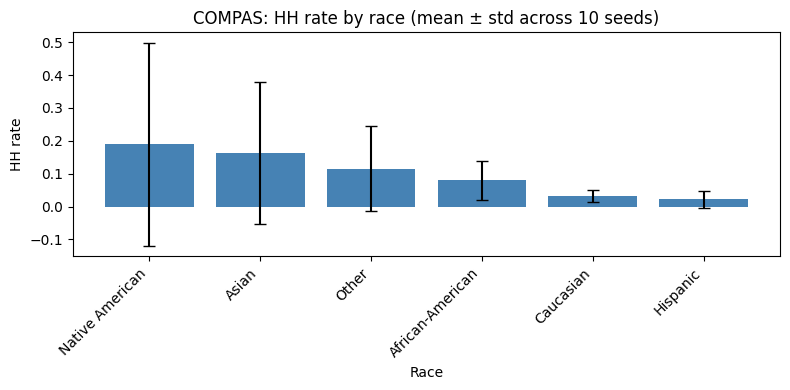

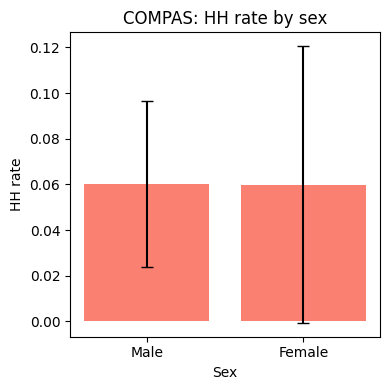

In [21]:
# Bar chart: HH rate by race (with error bars)
race_data = agg_fair[agg_fair["group_col"] == "race"].copy()
race_data = race_data.sort_values("hh_rate_mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(race_data["group_val"], race_data["hh_rate_mean"],
       yerr=race_data["hh_rate_std"], capsize=4, color="steelblue")
ax.set_ylabel("HH rate")
ax.set_xlabel("Race")
ax.set_title("COMPAS: HH rate by race (mean ± std across 10 seeds)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "fairness_hh_rate_by_race_compas.pdf", bbox_inches="tight")
plt.show()

# Sex
sex_data = agg_fair[agg_fair["group_col"] == "sex"].copy()

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(sex_data["group_val"], sex_data["hh_rate_mean"],
       yerr=sex_data["hh_rate_std"], capsize=4, color="salmon")
ax.set_ylabel("HH rate")
ax.set_xlabel("Sex")
ax.set_title("COMPAS: HH rate by sex")
plt.tight_layout()
fig.savefig(FIGURES / "fairness_hh_rate_by_sex_compas.pdf", bbox_inches="tight")
plt.show()

In [22]:
# Robustness check: kNN graph EXCLUDING protected attributes (race, sex)
# Column selection is derived from the fitted preprocessor's feature names per run.

from libpysal.weights import KNN as PySAL_KNN
from esda.moran import Moran, Moran_Local
from analysis.run_analysis import _fdr_benjamini_hochberg


def _get_non_protected_cols_for_run(run_dir):
    """Return preprocessed column indices that are NOT race/sex for this run."""
    X_compas, y_compas, fi_compas = load_dataset("compas")
    split = load_split(run_dir)
    pre = make_preprocessor(fi_compas, scale_numeric=True)
    pre.fit(X_compas.iloc[split["train"]], y_compas.iloc[split["train"]])
    feat_names = list(pre.get_feature_names_out())
    keep = [
        i for i, n in enumerate(feat_names)
        if ("cat__sex_" not in n and "cat__race_" not in n)
    ]
    return keep, feat_names


excl_rows = []
for seed in SEEDS:
    run_dir = RESULTS / "compas" / f"seed={seed}"
    try:
        P_test = load_P_test(run_dir)
        idx = select_rashomon_global(run_dir, K=K)
        P_sel = P_test[idx]
        v = pointwise_variance(P_sel)

        X_test_full = get_transformed_test_features(run_dir, "compas")
        if hasattr(X_test_full, "toarray"):
            X_test_full = X_test_full.toarray()
        X_test_full = np.asarray(X_test_full, dtype=float)

        non_prot_cols, feat_names = _get_non_protected_cols_for_run(run_dir)
        if X_test_full.shape[1] != len(feat_names):
            raise ValueError(
                f"Feature mismatch: transformed has {X_test_full.shape[1]} cols, "
                f"preprocessor reports {len(feat_names)}"
            )

        # Full graph (baseline)
        sp_full = spatial_analysis(v, X_test_full, k=K_NN, permutations=999)

        # Graph excluding protected attributes
        X_no_prot = X_test_full[:, non_prot_cols]
        W_np = PySAL_KNN.from_array(X_no_prot, k=K_NN)
        W_np.transform = "r"
        np.random.seed(42)
        moran_np = Moran(v, W_np, permutations=999)
        lm_np = Moran_Local(v, W_np, transformation="r", permutations=999, seed=42)
        p_sim_np = np.asarray(lm_np.p_sim).flatten()
        q_np = np.asarray(lm_np.q).flatten()
        sig_np = _fdr_benjamini_hochberg(p_sim_np, alpha=0.05)
        hh_np = (q_np == 1) & sig_np

        # Jaccard overlap
        hh_full = sp_full["HH_mask"]
        inter = np.logical_and(hh_full, hh_np).sum()
        union = np.logical_or(hh_full, hh_np).sum()
        jaccard = inter / union if union > 0 else 1.0

        excl_rows.append({
            "seed": seed,
            "moran_full": sp_full["moran_i"],
            "moran_excl_prot": float(moran_np.I),
            "n_hh_full": int(hh_full.sum()),
            "n_hh_excl_prot": int(hh_np.sum()),
            "jaccard_hh": jaccard,
        })
    except Exception as e:
        print(f"  seed={seed}: SKIP ({e})")


df_excl = pd.DataFrame(excl_rows)
print("kNN graph: full features vs. excluding race/sex (COMPAS)")
print(f"  Moran I   full: {df_excl['moran_full'].mean():.3f} +/- {df_excl['moran_full'].std():.3f}")
print(f"  Moran I   excl: {df_excl['moran_excl_prot'].mean():.3f} +/- {df_excl['moran_excl_prot'].std():.3f}")
print(f"  n_HH      full: {df_excl['n_hh_full'].mean():.1f} +/- {df_excl['n_hh_full'].std():.1f}")
print(f"  n_HH      excl: {df_excl['n_hh_excl_prot'].mean():.1f} +/- {df_excl['n_hh_excl_prot'].std():.1f}")
print(f"  Jaccard HH:     {df_excl['jaccard_hh'].mean():.3f} +/- {df_excl['jaccard_hh'].std():.3f}")
df_excl.to_csv(TABLES / "knn_excl_protected_compas.csv", index=False)

c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


kNN graph: full features vs. excluding race/sex (COMPAS)
  Moran I   full: 0.199 +/- 0.077
  Moran I   excl: 0.246 +/- 0.092
  n_HH      full: 86.7 +/- 55.0
  n_HH      excl: 119.6 +/- 69.6
  Jaccard HH:     0.479 +/- 0.130


---
## 4. Alternative kNN Graph Constructions

Test whether spatial results depend on the distance metric / representation.

In [23]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from libpysal.weights import KNN as PySAL_KNN
from libpysal.weights import W as PySAL_W
from esda.moran import Moran, Moran_Local


def build_cosine_knn_weights(X, k=30):
    """Build kNN graph using cosine distance, return PySAL weights."""
    X_norm = normalize(X, norm="l2")
    nn = NearestNeighbors(n_neighbors=k + 1, metric="cosine", algorithm="brute")
    nn.fit(X_norm)
    distances, indices = nn.kneighbors(X_norm)
    
    neighbors = {}
    weights = {}
    for i in range(X.shape[0]):
        neighbors[i] = indices[i, 1:].tolist()  # exclude self -> k neighbors
        w = np.ones(k)
        w = w / w.sum()
        weights[i] = w.tolist()
    
    return PySAL_W(neighbors, weights)


def build_pca_knn_weights(X, n_components=15, k=30):
    """Build kNN graph in PCA-reduced space, return PySAL weights."""
    n_components = min(n_components, X.shape[1], X.shape[0])
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    W = PySAL_KNN.from_array(X_pca, k=k)
    W.transform = "r"
    return W


def spatial_with_custom_W(v, W, permutations=999, fdr_alpha=0.05, seed=42):
    """Compute Moran's I + LISA with a pre-built weights matrix."""
    if seed is not None:
        np.random.seed(seed)
    moran_g = Moran(v, W, permutations=permutations)
    lm = Moran_Local(v, W, transformation="r", permutations=permutations, seed=seed)
    
    p_sim = np.asarray(lm.p_sim).flatten()
    q = np.asarray(lm.q).flatten()
    
    from analysis.run_analysis import _fdr_benjamini_hochberg
    sig = _fdr_benjamini_hochberg(p_sim, alpha=fdr_alpha)
    hh_mask = (q == 1) & sig
    
    return {
        "moran_i": float(moran_g.I),
        "moran_p": float(moran_g.p_sim),
        "n_hh": int(hh_mask.sum()),
        "HH_mask": hh_mask,
    }

In [24]:
alt_rows = []

for dataset in DATASETS:
    for seed in SEEDS:
        run_dir = RESULTS / dataset / f"seed={seed}"
        try:
            P_test = load_P_test(run_dir)
            idx = select_rashomon_global(run_dir, K=K)
            P_sel = P_test[idx]
            v = pointwise_variance(P_sel)
            X_test = get_transformed_test_features(run_dir, dataset)
            
            # Baseline: Euclidean kNN
            sp_base = spatial_analysis(v, X_test, k=K_NN, permutations=999)
            alt_rows.append({
                "dataset": dataset, "seed": seed, "method": "euclidean",
                "moran_i": sp_base["moran_i"],
                "n_hh": int(sp_base["HH_mask"].sum()),
            })
            
            # PCA kNN (15 components)
            W_pca = build_pca_knn_weights(X_test, n_components=15, k=K_NN)
            sp_pca = spatial_with_custom_W(v, W_pca)
            alt_rows.append({
                "dataset": dataset, "seed": seed, "method": "pca_15",
                "moran_i": sp_pca["moran_i"],
                "n_hh": sp_pca["n_hh"],
            })
            
            # Cosine kNN
            W_cos = build_cosine_knn_weights(X_test, k=K_NN)
            sp_cos = spatial_with_custom_W(v, W_cos)
            alt_rows.append({
                "dataset": dataset, "seed": seed, "method": "cosine",
                "moran_i": sp_cos["moran_i"],
                "n_hh": sp_cos["n_hh"],
            })
            
            if seed == 0:
                print(f"  {dataset} seed={seed}: euc={sp_base['moran_i']:.3f}, "
                      f"pca={sp_pca['moran_i']:.3f}, cos={sp_cos['moran_i']:.3f}")
        except Exception as e:
            print(f"  {dataset} seed={seed}: SKIP ({e})")

df_alt = pd.DataFrame(alt_rows)
print(f"\nCollected {len(df_alt)} alternative graph rows")

  compas seed=0: euc=0.141, pca=0.141, cos=0.156
  german seed=0: euc=0.116, pca=0.110, cos=0.136
  breast_cancer seed=0: euc=0.034, pca=0.035, cos=0.047

Collected 90 alternative graph rows


In [25]:
# Summary table: mean ± std per method per dataset
agg_alt = df_alt.groupby(["dataset", "method"]).agg(
    moran_mean=("moran_i", "mean"),
    moran_std=("moran_i", "std"),
    hh_mean=("n_hh", "mean"),
    hh_std=("n_hh", "std"),
    n_seeds=("seed", "count"),
).reset_index()

print("Alternative kNN graph comparison (mean ± std across seeds):")
display(agg_alt)

agg_alt.to_csv(TABLES / "alternative_knn_comparison.csv", index=False)

Alternative kNN graph comparison (mean ± std across seeds):


,dataset,method,moran_mean,moran_std,hh_mean,hh_std,n_seeds
0,breast_cancer,cosine,0.034328,0.022119,0.5,1.080123,10
1,breast_cancer,euclidean,0.031547,0.020719,1.6,2.988868,10
2,breast_cancer,pca_15,0.032761,0.021725,1.8,3.359894,10
3,compas,cosine,0.209978,0.082902,114.9,50.766240,10
4,compas,euclidean,0.199279,0.077227,86.7,55.001111,10
5,compas,pca_15,0.198016,0.075869,82.2,50.070617,10
6,german,cosine,0.112340,0.043308,6.2,4.779586,10
7,german,euclidean,0.104155,0.039695,2.7,2.213594,10
8,german,pca_15,0.098329,0.039897,3.0,2.211083,10


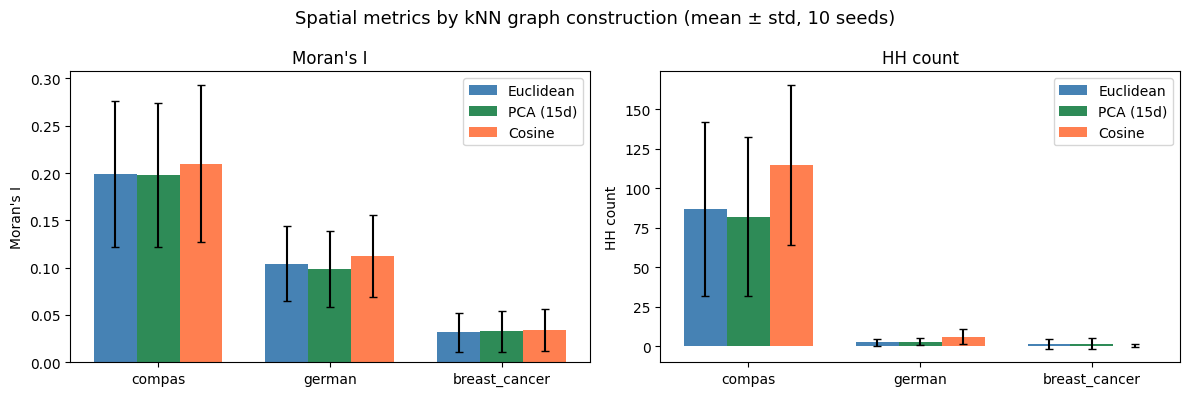

In [26]:
# Grouped bar plot: Moran's I by method for each dataset
methods = ["euclidean", "pca_15", "cosine"]
method_labels = ["Euclidean", "PCA (15d)", "Cosine"]
colors = ["steelblue", "seagreen", "coral"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax_idx, metric in enumerate(["moran_i", "n_hh"]):
    ax = axes[ax_idx]
    x = np.arange(len(DATASETS))
    width = 0.25
    
    for i, (method, label, color) in enumerate(zip(methods, method_labels, colors)):
        sub = agg_alt[agg_alt["method"] == method]
        means = []
        stds = []
        for ds in DATASETS:
            row = sub[sub["dataset"] == ds]
            if len(row):
                col_mean = "moran_mean" if metric == "moran_i" else "hh_mean"
                col_std = "moran_std" if metric == "moran_i" else "hh_std"
                means.append(row[col_mean].values[0])
                stds.append(row[col_std].values[0])
            else:
                means.append(0)
                stds.append(0)
        
        ax.bar(x + i * width, means, width, yerr=stds, label=label,
               color=color, capsize=3)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(DATASETS)
    ax.set_ylabel("Moran's I" if metric == "moran_i" else "HH count")
    ax.set_title("Moran's I" if metric == "moran_i" else "HH count")
    ax.legend()

fig.suptitle("Spatial metrics by kNN graph construction (mean ± std, 10 seeds)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / "alternative_knn_comparison.pdf", bbox_inches="tight")
plt.show()

---
## Summary

Saved tables:
- `tables/family_importance_aggregated.csv`
- `tables/hp_importance_aggregated_top5.csv`
- `tables/variance_vs_margin_summary.csv`
- `tables/margin_hh_wilcoxon.csv`
- `tables/fairness_subgroup_rates_compas.csv`
- `tables/fairness_permutation_test_compas.csv`
- `tables/alternative_knn_comparison.csv`

Saved figures:
- `figures/family_importance_aggregated.pdf`
- `figures/hp_importance_aggregated_compas.pdf`
- `figures/variance_vs_margin_compas.pdf`
- `figures/fairness_hh_rate_by_race_compas.pdf`
- `figures/fairness_hh_rate_by_sex_compas.pdf`
- `figures/alternative_knn_comparison.pdf`